## Класифікація Fashion-MNIST за допомогою Keras

Oпис датасету:
https://www.tensorflow.org/datasets/catalog/fashion_mnist

In [15]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

tf.keras.utils.set_random_seed(42)


### Завантаження датасету

In [16]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

### Назви класів та приклади зображень

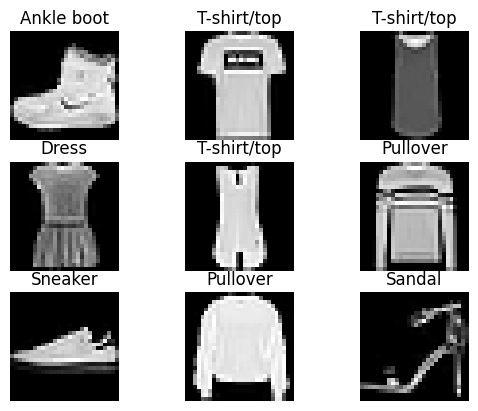

In [17]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure()
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.show()

### Попередня обробка даних

In [18]:
x_train = (x_train.astype("float32") / 255.0)[..., np.newaxis]
x_test  = (x_test.astype("float32") / 255.0)[..., np.newaxis]

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)

x_train: (60000, 28, 28, 1)
x_test: (10000, 28, 28, 1)


### Побудова data pipeline

In [19]:
x_val, y_val = x_train[-10000:], y_train[-10000:]
x_train2, y_train2 = x_train[:-10000], y_train[:-10000]
train_ds = tf.data.Dataset.from_tensor_slices(
    (x_train2, y_train2)
).shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (x_val, y_val)
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(
    (x_test, y_test)
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [20]:
for xb, yb in train_ds.take(1):
    print("Batch x shape:", xb.shape)
    print("Batch y shape:", yb.shape)

Batch x shape: (128, 28, 28, 1)
Batch y shape: (128,)


### Mодель CNN

In [21]:
inputs = tf.keras.layers.Input(shape=(28, 28, 1))
x = inputs

x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)

x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(10, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,818 (1.78 MB)

 Trainable params: 467,818 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

### Callbacks

In [22]:
class StopOnValAccDropAfterTarget(tf.keras.callbacks.Callback):
    def __init__(self, target=0.91, monitor="val_accuracy", verbose=1):
        super().__init__()
        self.target = target
        self.monitor = monitor
        self.verbose = verbose
        self.prev = None
        self.target_reached = False

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)

        if current is None:
            return

        if current >= self.target:
            self.target_reached = True

        if self.target_reached and self.prev is not None and self.prev > current:
            if self.verbose:
                print(
                    f"\nStopped: {self.monitor} dropped from {self.prev:.4f} to {current:.4f} "
                    f"after reaching target {self.target:.2f}."
                )
            self.model.stop_training = True

        self.prev = current
        
callbacks = [
    StopOnValAccDropAfterTarget(target=0.91, monitor="val_accuracy", verbose=1),
]

### Навчання CNN

In [23]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=2
)


test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")


Epoch 1/50
391/391 - 21s - 55ms/step - accuracy: 0.7923 - loss: 0.5672 - val_accuracy: 0.8719 - val_loss: 0.3409
Epoch 2/50
391/391 - 19s - 48ms/step - accuracy: 0.8777 - loss: 0.3359 - val_accuracy: 0.8934 - val_loss: 0.2779
Epoch 3/50
391/391 - 18s - 47ms/step - accuracy: 0.8968 - loss: 0.2856 - val_accuracy: 0.9111 - val_loss: 0.2402
Epoch 4/50
391/391 - 17s - 44ms/step - accuracy: 0.9069 - loss: 0.2545 - val_accuracy: 0.9139 - val_loss: 0.2335
Epoch 5/50
391/391 - 17s - 44ms/step - accuracy: 0.9145 - loss: 0.2338 - val_accuracy: 0.9229 - val_loss: 0.2134
Epoch 6/50
391/391 - 19s - 47ms/step - accuracy: 0.9210 - loss: 0.2154 - val_accuracy: 0.9259 - val_loss: 0.2036
Epoch 7/50
391/391 - 22s - 56ms/step - accuracy: 0.9255 - loss: 0.2038 - val_accuracy: 0.9271 - val_loss: 0.1979
Epoch 8/50
391/391 - 22s - 56ms/step - accuracy: 0.9288 - loss: 0.1918 - val_accuracy: 0.9305 - val_loss: 0.1919
Epoch 9/50

Stopped: val_accuracy dropped from 0.9305 to 0.9298 after reaching target 0.91.
391/

### Аналіз навчання

In [24]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 0.9241
Test loss: 0.2062


### Графіки accuracy та loss

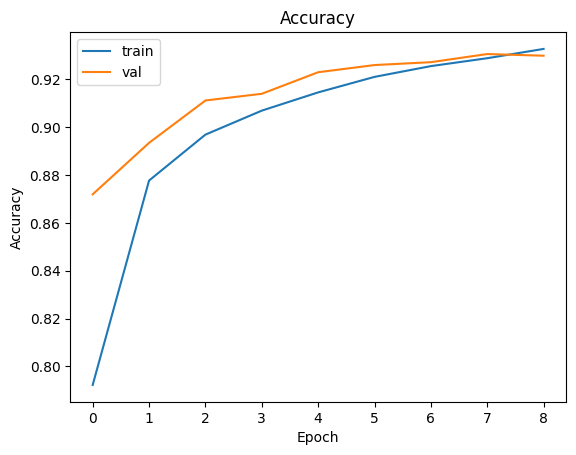

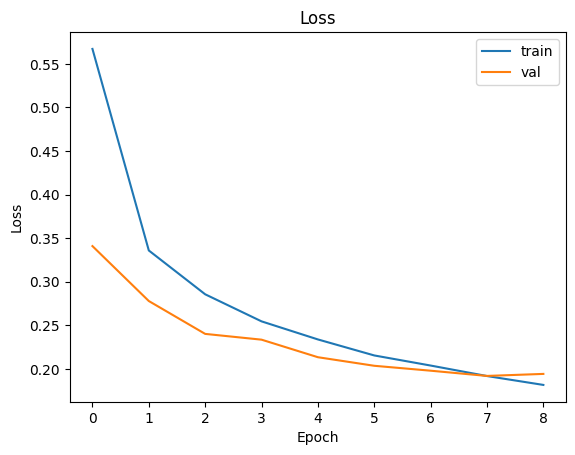

In [25]:
plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["train", "val"])
plt.show()

plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["train", "val"])
plt.show()


### Діагностика проблем навчання

In [26]:
train_acc = history.history["accuracy"][-1]
val_acc = history.history["val_accuracy"][-1]
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

print("Last epoch train acc:", train_acc)
print("Last epoch val acc:", val_acc)
print("Last epoch train loss:", train_loss)
print("Last epoch val loss:", val_loss)

if train_acc < 0.90 and val_acc < 0.90:
    print("underfitting.")
elif train_acc - val_acc > 0.03 and val_loss > train_loss:
    print("overfitting.")
else:
    print("training ok.")

Last epoch train acc: 0.932640016078949
Last epoch val acc: 0.9297999739646912
Last epoch train loss: 0.18161241710186005
Last epoch val loss: 0.19425150752067566
training ok.


### Приклади *неправильних* прогнозів

In [32]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

y_pred_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

wrong_idx = np.where(y_pred != y_test)[0]
correct_idx = np.where(y_pred == y_test)[0]

Кількість помилкових класифікацій: 759


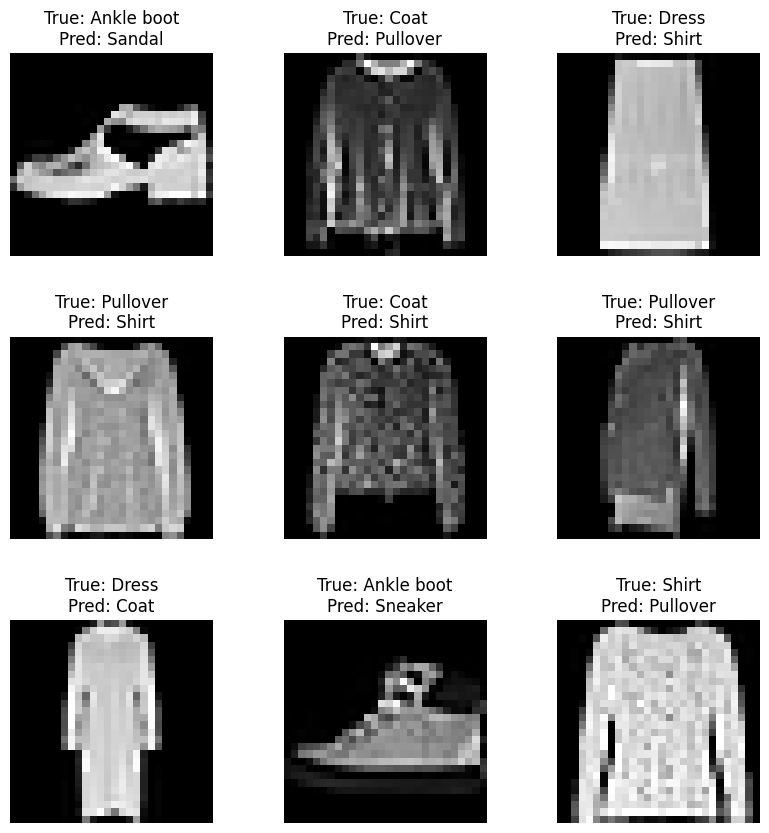

In [34]:
print(f"Кількість помилкових класифікацій: {len(wrong_idx)}")

n_show = min(9, len(wrong_idx))

plt.figure(figsize=(10, 10))

for i, idx in enumerate(wrong_idx[:n_show]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap="gray")
    plt.title(
        f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}"
    )
    plt.axis("off")

plt.subplots_adjust(hspace=0.4)
plt.show()

### Приклади *правильних* передбачень

Кількість правильних класифікацій: 9241


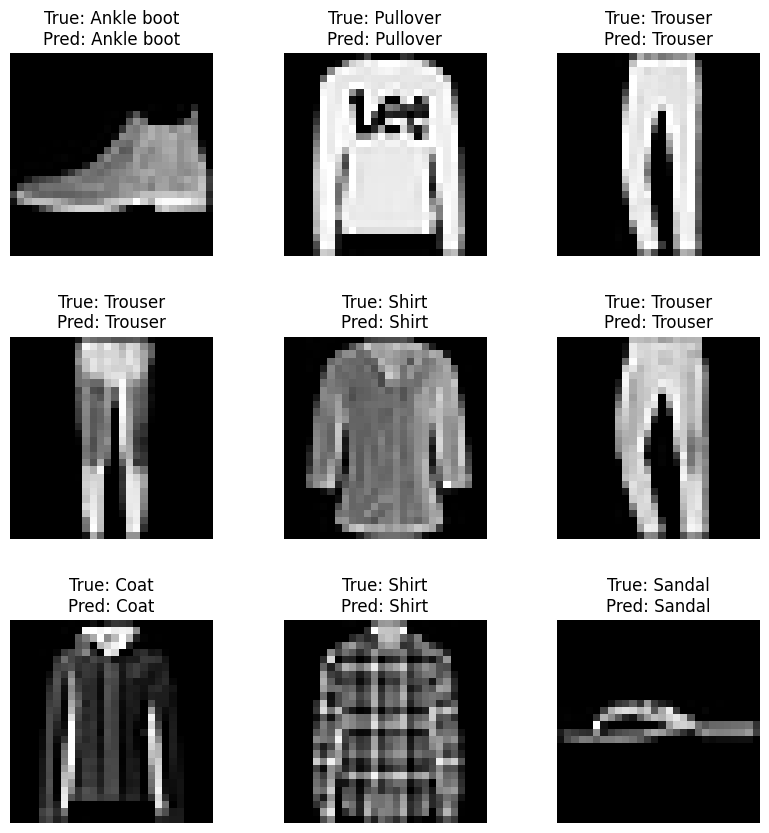

In [36]:
print(f"Кількість правильних класифікацій: {len(correct_idx)}")

# Show up to 9 correct examples
n_show = min(9, len(correct_idx))

plt.figure(figsize=(10, 10))

for i, idx in enumerate(correct_idx[:n_show]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap="gray")
    plt.title(
        f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}"
    )
    plt.axis("off")

plt.subplots_adjust(hspace=0.4)
plt.show()

## Висновки

- CNN-модель, що використовує згорткові шари, витягує просторові ознаки зображень.
- Використання Dropout зменшує ризик перенавчання.
- Отримана точність на тесті відповідає вимозі "не нижчою 91%"